In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
OCORRENCIAS = r'C:\Users\eduarda.castilho\Documents\UC2_aulas\aula05_UC2\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\Users\eduarda.castilho\Documents\UC2_aulas\BASES\08.DP.csv'

df_ocorrencias = pd.read_csv(
    OCORRENCIAS,
    sep=';',
    encoding= 'iso-8859-1'
)

df_DP = pd.read_csv(
    DP

)

df_DP.head(10)

,codDP,nome,endereco
0,1,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."
5,9,009ª DP - Catete,"Rua Pedro Américo, 1 - Catete, Rio de Janeiro ..."
6,10,010ª DP - Botafogo,"Rua Bambina, 140 - Botafogo, Rio de Janeiro - ..."
7,11,011ª DP - Rocinha,"Rua Bertha Lutz, 80 - Gávea, Rio de Janeiro - ..."
8,12,012ª DP - Copacabana,"Rua Hilário de Gouveia, 102 - Copacabana, Rio ..."
9,13,013ª DP - Ipanema,"Avenida Nossa Senhora de Copacabana, 1260 - Co..."


In [3]:
df_merge = df_ocorrencias.merge(
    df_DP,
    how='left',
    right_on='codDP',
    left_on= 'cisp'
)

df_merge.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,codDP,nome,endereco
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,2,0,0,0,0,578,3,1.0,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,6,0,1,0,0,441,3,4.0,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,2,1,0,0,0,637,3,5.0,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,2,1,0,0,0,473,3,6.0,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,1,3,0,0,0,147,3,7.0,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."


In [4]:
df_roubo_banco = df_merge[[
        'cisp', 'nome', 'roubo_banco',
        'munic', 'regiao', 'ano'
]]

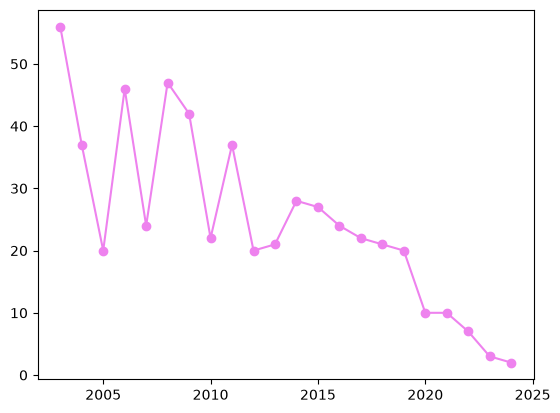

C:\Users\eduarda.castilho\AppData\Local\Temp\ipykernel_8372\4099884474.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_banco_por_ano['roubo_banco'],


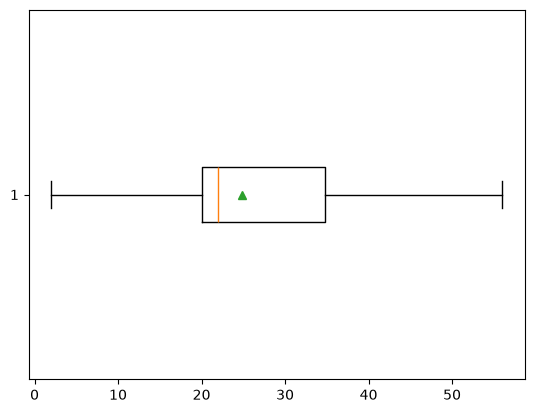

In [5]:
df_roubo_banco_por_ano = (
    df_roubo_banco.groupby('ano')['roubo_banco'].sum().reset_index().sort_values(by='ano', ascending = False)
)

plt.plot(df_roubo_banco_por_ano['ano'], df_roubo_banco_por_ano['roubo_banco'], marker='o', color = 'violet')
plt.show()
plt.boxplot(df_roubo_banco_por_ano['roubo_banco'],
            showfliers=True,
            showmeans=True,
            vert=False)

plt.show()

In [6]:
assimetria = df_roubo_banco_por_ano['roubo_banco'].skew()
curtose = df_roubo_banco_por_ano['roubo_banco'].kurtosis()

print(f'Assimetria: {assimetria:.4f}')
print(f'Curtose: {curtose:.4f}')

Assimetria: 0.4254
Curtose: -0.2634


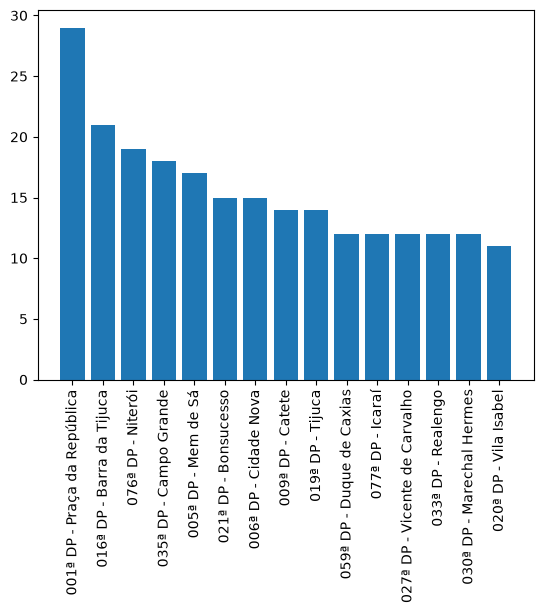

In [31]:
df_roubo_banco_por_dp = (
    df_roubo_banco.groupby('nome')['roubo_banco']
    .sum().reset_index()
    .sort_values(by='roubo_banco', ascending = False)
)
df_roubo_banco_por_dp = df_roubo_banco_por_dp.iloc[0:15]
plt.bar(df_roubo_banco_por_dp['nome'], df_roubo_banco_por_dp['roubo_banco'])
plt.xticks(rotation=90)
plt.show()

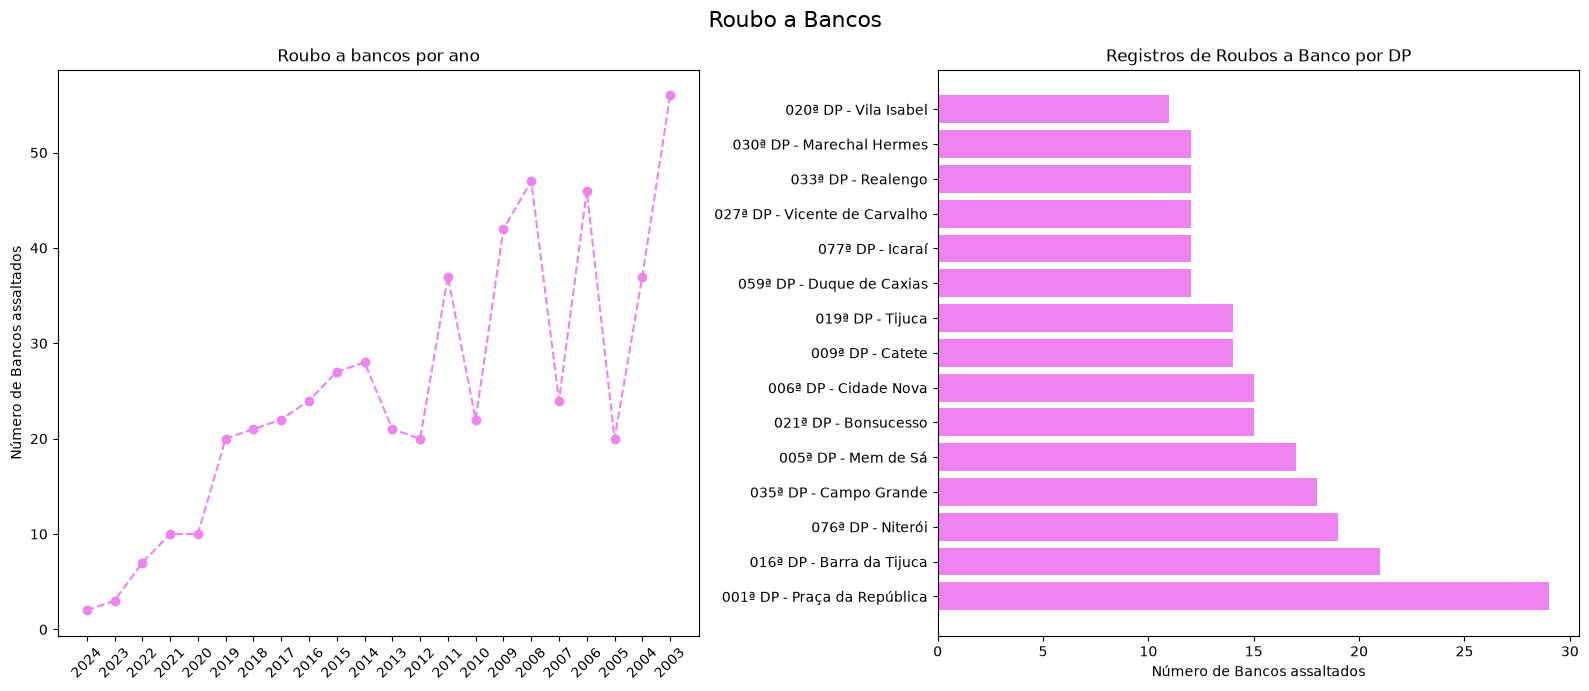

In [39]:
# "painel" de graficos 
# 1. criar uma area para os graficos
plt.subplots(1, 2, figsize=(16, 7))
# (numLinhas, numColunas, tamanhoImagem)
plt.suptitle('Roubo a Bancos', fontsize=16)
#titulo dos plots (imagem)
# subplot -> (x, y, z) -> x e y repetem valor dos subplots
# z -> posição do grafico no subplot 
plt.subplot(1, 2, 1) #primeiro grafico
plt.plot(df_roubo_banco_por_ano['ano'].astype(str), df_roubo_banco_por_ano['roubo_banco'],
         marker='o', color='violet', linestyle='--')
plt.ylabel('Número de Bancos assaltados')
plt.title('Roubo a bancos por ano')
plt.xticks(rotation=45)

#segundo grafico
plt.subplot(1, 2, 2)
plt.barh(df_roubo_banco_por_dp['nome'], df_roubo_banco_por_dp['roubo_banco'],
        color= 'violet')
plt.xlabel('Número de Bancos assaltados')
plt.title('Registros de Roubos a Banco por DP')
plt.xticks(rotation=0)
plt.tight_layout() #-> layout mais justo
plt.show()